In [ ]:
!pip install xgboost -q

In [ ]:
import pandas as pd
import numpy as np
import os
import glob
import time

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving final(2).csv to final(2).csv


In [ ]:
os.listdir("/content")

['.config', 'final(2).csv', 'sample_data']

In [ ]:
csv_files = glob.glob("/content/*.csv")
csv_files

['/content/final(2).csv']

In [ ]:
csv_path = csv_files[0]
print("Archivo CSV encontrado:", csv_path)

Archivo CSV encontrado: /content/final(2).csv


In [ ]:
df = pd.read_csv(csv_path)

df.head()

,Time,Protcol,Flag,Family,Clusters,SeddAddress,ExpAddress,BTC,USD,Netflow_Bytes,IPaddress,Threats,Port,Prediction
0,50,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,500,5,A,Bonet,5061,SS
1,40,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,504,8,A,Bonet,5061,SS
2,30,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,508,7,A,Bonet,5061,SS
3,20,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,512,15,A,Bonet,5061,SS
4,57,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,516,9,A,Bonet,5061,SS


In [ ]:
print("Filas y columnas:", df.shape)

Filas y columnas: (149043, 14)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149043 entries, 0 to 149042
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Time           149043 non-null  int64 
 1   Protcol        149043 non-null  object
 2   Flag           149043 non-null  object
 3   Family         149043 non-null  object
 4   Clusters       149043 non-null  int64 
 5   SeddAddress    149043 non-null  object
 6   ExpAddress     149043 non-null  object
 7   BTC            149043 non-null  int64 
 8   USD            149043 non-null  int64 
 9   Netflow_Bytes  149043 non-null  int64 
 10  IPaddress      149043 non-null  object
 11  Threats        149043 non-null  object
 12  Port           149043 non-null  int64 
 13  Prediction     149043 non-null  object
dtypes: int64(6), object(8)
memory usage: 15.9+ MB


In [ ]:
df.columns

Index(['Time', 'Protcol', 'Flag', 'Family', 'Clusters', 'SeddAddress',
       'ExpAddress', 'BTC', 'USD', 'Netflow_Bytes', 'IPaddress', 'Threats',
       'Port', 'Prediction'],
      dtype='object')

In [ ]:
df = df.rename(columns={
    "Protcol": "Protocol",
    "SeddAddress": "SeedAddress"
})

df.columns

Index(['Time', 'Protocol', 'Flag', 'Family', 'Clusters', 'SeedAddress',
       'ExpAddress', 'BTC', 'USD', 'Netflow_Bytes', 'IPaddress', 'Threats',
       'Port', 'Prediction'],
      dtype='object')

In [ ]:
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
Time             0
Protocol         0
Flag             0
Family           0
Clusters         0
SeedAddress      0
ExpAddress       0
BTC              0
USD              0
Netflow_Bytes    0
IPaddress        0
Threats          0
Port             0
Prediction       0
dtype: int64


In [ ]:
print("Filas duplicadas:", df.duplicated().sum())

Filas duplicadas: 0


In [ ]:
df = df.drop_duplicates()

print("Nuevo tamaño del dataset:", df.shape)

Nuevo tamaño del dataset: (149043, 14)


In [ ]:
df["Prediction"].value_counts()

,count
Prediction,
S,66380
A,42561
SS,40102


In [ ]:
df["is_ransomware"] = df["Prediction"].astype(str).str.upper().apply(
    lambda x: 0 if x == "A" else 1
)

df["is_ransomware"].value_counts()

,count
is_ransomware,
1,106482
0,42561


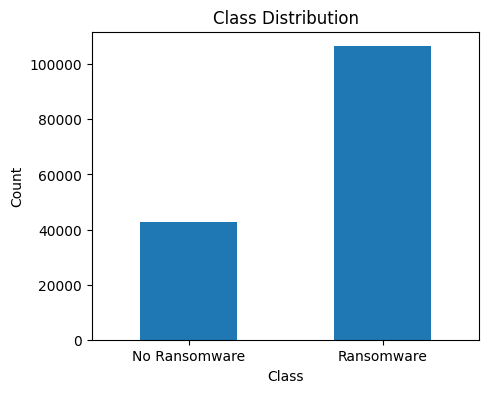

In [ ]:
# Grafica la cantidad de registros por clase para visualizar si el dataset está balanceado.
conteo = df["is_ransomware"].value_counts().sort_index()

conteo.plot(kind="bar", figsize=(5, 4))
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks([0, 1], ["No Ransomware", "Ransomware"], rotation=0)
plt.show()

In [ ]:
USE_FAMILY_FEATURE = True

In [ ]:
drop_columns = ["Prediction", "is_ransomware"]

if USE_FAMILY_FEATURE == False:
    drop_columns.append("Family")

X = df.drop(columns=drop_columns)
y = df["is_ransomware"]

print("Columnas usadas para entrenar:")
print(X.columns)

print("Tamaño de X:", X.shape)
print("Tamaño de y:", y.shape)

Columnas usadas para entrenar:
Index(['Time', 'Protocol', 'Flag', 'Family', 'Clusters', 'SeedAddress',
       'ExpAddress', 'BTC', 'USD', 'Netflow_Bytes', 'IPaddress', 'Threats',
       'Port'],
      dtype='object')
Tamaño de X: (149043, 13)
Tamaño de y: (149043,)


Transformacion texto a numero usando OneHotEncoder

---



In [ ]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Columnas categóricas:", categorical_cols)
print("Columnas numéricas:", numerical_cols)

Columnas categóricas: ['Protocol', 'Flag', 'Family', 'SeedAddress', 'ExpAddress', 'IPaddress', 'Threats']
Columnas numéricas: ['Time', 'Clusters', 'BTC', 'USD', 'Netflow_Bytes', 'Port']


In [ ]:
try:
    onehot = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True,
        min_frequency=10
    )
except TypeError:
    onehot = OneHotEncoder(
        handle_unknown="ignore",
        sparse=True
    )

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", onehot, categorical_cols),
        ("num", StandardScaler(with_mean=False), numerical_cols)
    ]
)

In [ ]:
#Seleccionamos 80% de training
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (119234, 13)
X_test: (29809, 13)
y_train: (119234,)
y_test: (29809,)


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        n_jobs=-1
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=12,
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=14,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.8,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        tree_method="hist",
        random_state=42
    )
}

In [ ]:
results = []
trained_models = {}

for name, model in models.items():
    print("=" * 80)
    print("Entrenando modelo:", name)

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    start_train = time.time()
    pipeline.fit(X_train, y_train)
    end_train = time.time()

    start_pred = time.time()
    y_pred = pipeline.predict(X_test)
    end_pred = time.time()

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    try:
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    except:
        auc = np.nan

    train_time = end_train - start_train
    pred_time = end_pred - start_pred

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "ROC-AUC": auc,
        "Training Time (s)": train_time,
        "Prediction Time (s)": pred_time
    })

    trained_models[name] = pipeline

    print(classification_report(y_test, y_pred))
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))

Entrenando modelo: Logistic Regression
              precision    recall  f1-score   support

           0       0.75      0.90      0.81      8512
           1       0.95      0.88      0.91     21297

    accuracy                           0.88     29809
   macro avg       0.85      0.89      0.86     29809
weighted avg       0.90      0.88      0.89     29809

Matriz de confusión:
[[ 7625   887]
 [ 2598 18699]]
Entrenando modelo: Decision Tree
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      8512
           1       1.00      0.99      1.00     21297

    accuracy                           0.99     29809
   macro avg       0.99      0.99      0.99     29809
weighted avg       0.99      0.99      0.99     29809

Matriz de confusión:
[[ 8491    21]
 [  163 21134]]
Entrenando modelo: Random Forest
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      8512
           1       1.00     

In [ ]:
results_df = pd.DataFrame(results)

results_df.sort_values(by="F1-score", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Training Time (s),Prediction Time (s)
4,XGBoost,0.995807,0.996902,0.997230,0.997066,0.999941,3.066708,0.223552
1,Decision Tree,0.993827,0.999007,0.992346,0.995666,0.998892,2.084252,0.064937
2,Random Forest,0.992989,0.998393,0.991783,0.995077,0.999709,34.390903,0.707509
3,AdaBoost,0.935556,0.938292,0.973846,0.955738,0.976199,12.577361,0.432981
0,Logistic Regression,0.883089,0.954713,0.878011,0.914757,0.956616,39.567254,0.067802


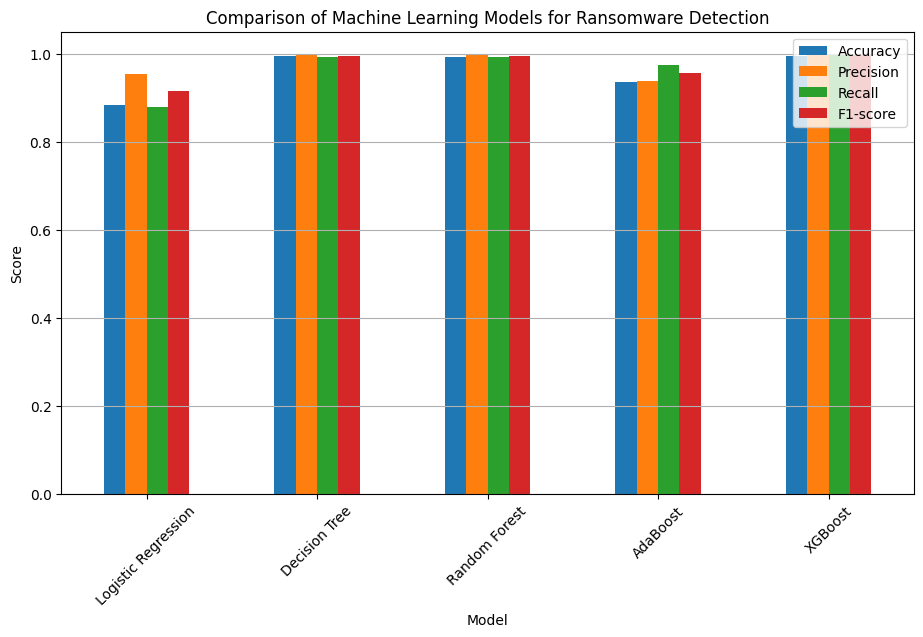

In [ ]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Comparison of Machine Learning Models for Ransomware Detection")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [ ]:
best_model_name = results_df.sort_values(by="F1-score", ascending=False).iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Mejor modelo según F1-score:", best_model_name)

Mejor modelo según F1-score: XGBoost


PRUEBA CON FILA RANSOMWARE


In [ ]:
# Buscar una muestra real etiquetada como ransomware dentro del dataset
ransomware_sample = df[df["is_ransomware"] == 1].sample(1, random_state=10)

ransomware_sample

,Time,Protocol,Flag,Family,Clusters,SeedAddress,ExpAddress,BTC,USD,Netflow_Bytes,IPaddress,Threats,Port,Prediction,is_ransomware
22893,15,TCP,R,EDA2,1,1NKi9AK5,1SYSTEMQ,22,18126,4906,C,DoS,5066,S,1


In [ ]:
# Preparar la muestra con las mismas columnas usadas en X
sample_X = ransomware_sample[X.columns]

sample_X

,Time,Protocol,Flag,Family,Clusters,SeedAddress,ExpAddress,BTC,USD,Netflow_Bytes,IPaddress,Threats,Port
22893,15,TCP,R,EDA2,1,1NKi9AK5,1SYSTEMQ,22,18126,4906,C,DoS,5066


In [ ]:
prediction = best_model.predict(sample_X)[0]
probability = best_model.predict_proba(sample_X)[0][1]

print("Predicción:", prediction)
print("Probabilidad de ransomware:", probability)

if prediction == 1:
    print("Resultado: Ransomware detectado")
else:
    print("Resultado: No ransomware")

Predicción: 1
Probabilidad de ransomware: 0.999969
Resultado: Ransomware detectado


PRUEBA CON FILA NO RANSOMWARE

In [ ]:
benign_sample = df[df["is_ransomware"] == 0].sample(1, random_state=20)

sample_X = benign_sample[X.columns]

prediction = best_model.predict(sample_X)[0]
probability = best_model.predict_proba(sample_X)[0][1]

print("Predicción:", prediction)
print("Probabilidad de ransomware:", probability)

if prediction == 1:
    print("Resultado: Ransomware detectado")
else:
    print("Resultado: No ransomware")

Predicción: 0
Probabilidad de ransomware: 0.00064727024
Resultado: No ransomware
